# exp_021 · Level 2 — Velocity Field (`v_pred`)

`v_pred[τ, :, p, :, :]` is the **flow-matching velocity prediction** at denoising step τ,
latent frame p.  Same shape as `z_t`: `[S=40, C=128, F'=16, H'=16, W'=24]`.

---

### What the velocity encodes

In flow matching (LTX-2's training objective), the velocity `v_θ` estimates the direction
from the current noisy state toward the clean target:

$$v_\theta(z_\tau, \tau, c) \approx z_0 - z_\tau \cdot (1 - \tau/T)^{-1}$$

The magnitude `‖v_pred[τ,:,p,:,:]‖` directly measures **how hard the model is working
to move frame p at step τ**.

---

### Why velocity is the primary transition detector

A frame undergoing a hard dissolve must travel a large distance in latent space
(its noise-free target is semantically very different from its neighbours).
Its velocity norm will be **persistently high across all 40 denoising steps**.

Visualised as the `pred_mag` heatmap (τ × p), this appears as a
**vertical bright stripe** at the transition frame `p*` — visible even from the
earliest denoising steps.

> **Green solid line** = ground-truth transition annotation throughout this notebook.


In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve()))  # find trajectory_utils.py

from trajectory_utils import *

# Load all 10 samples (extracts features, frees raw tensors)
records = load_all_records()

# Load manual GT transition annotations
gt_dict = load_gt_annotations()

n_gt = sum(1 for v in gt_dict.values() if v is not None)
print(f"\n✓ GT annotations available for {n_gt}/{len(gt_dict)} samples")
for sid, gs in sorted(gt_dict.items()):
    gp_str = f"  p≈{gt_latent(sid, gt_dict):.1f}" if gs is not None else "  —"
    gs_str = f"{gs:.2f}s" if gs is not None else " —"
    print(f"  {sid:<50s}  {gs_str:>7s}{gp_str}")


✓ Loaded 10 samples  (raw tensors freed)
sample_id                                          cls  dis_by_step_final
─────────────────────────────────────────────────────────────────────────
  class1__blackswan__mallard-water                  1    p_commit=12 (4.00s)
  class2__mallard-fly__mallard-water                2    p_commit=12 (4.00s)
  class2__motocross-bumps__motocross-jump           2    p_commit=12 (4.00s)
  class2__paragliding-launch__paragliding           2    p_commit=12 (4.00s)
  class5__breakdance-flare__breakdance              5    p_commit= 8 (2.67s)
  class5__car-roundabout__bus                       5    p_commit= 9 (3.00s)
  class5__car-turn__car-shadow                      5    p_commit=12 (4.00s)
  class5__lucia__hike                               5    p_commit=12 (4.00s)
  class6__longboard__kite-surf                      6    p_commit= 1 (0.33s)
  class8__blackswan__boat                           8    p_commit= 1 (0.33s)

✓ GT annotations available for 9/10 samp

---
## 2.1 — Velocity Magnitude Heatmap (`pred_mag`)

One heatmap per sample (5 per row).  
x-axis = latent frame p (0–15) · y-axis = denoising step τ (row 0 = noisiest).  
Colour = `‖v_θ(z_τ, τ, c)(p)‖₂`, one global colour scale across all 10 heatmaps.

**Pattern guide:**

| Visual pattern | Meaning |
|----------------|---------|
| **Vertical bright stripe across all τ at frame p** | Transition is at frame p, committed from the first step. |
| **Bright stripe only in bottom rows (τ=25..39)** | Transition decided late — model was uncertain early. |
| **Uniformly bright across all frames** | No single transition frame — similar clips (expected for class 1). |
| **Bright at magenta region (p=12..15)** | Expected artefact from end-clip conditioning, not a dissolve signal. |


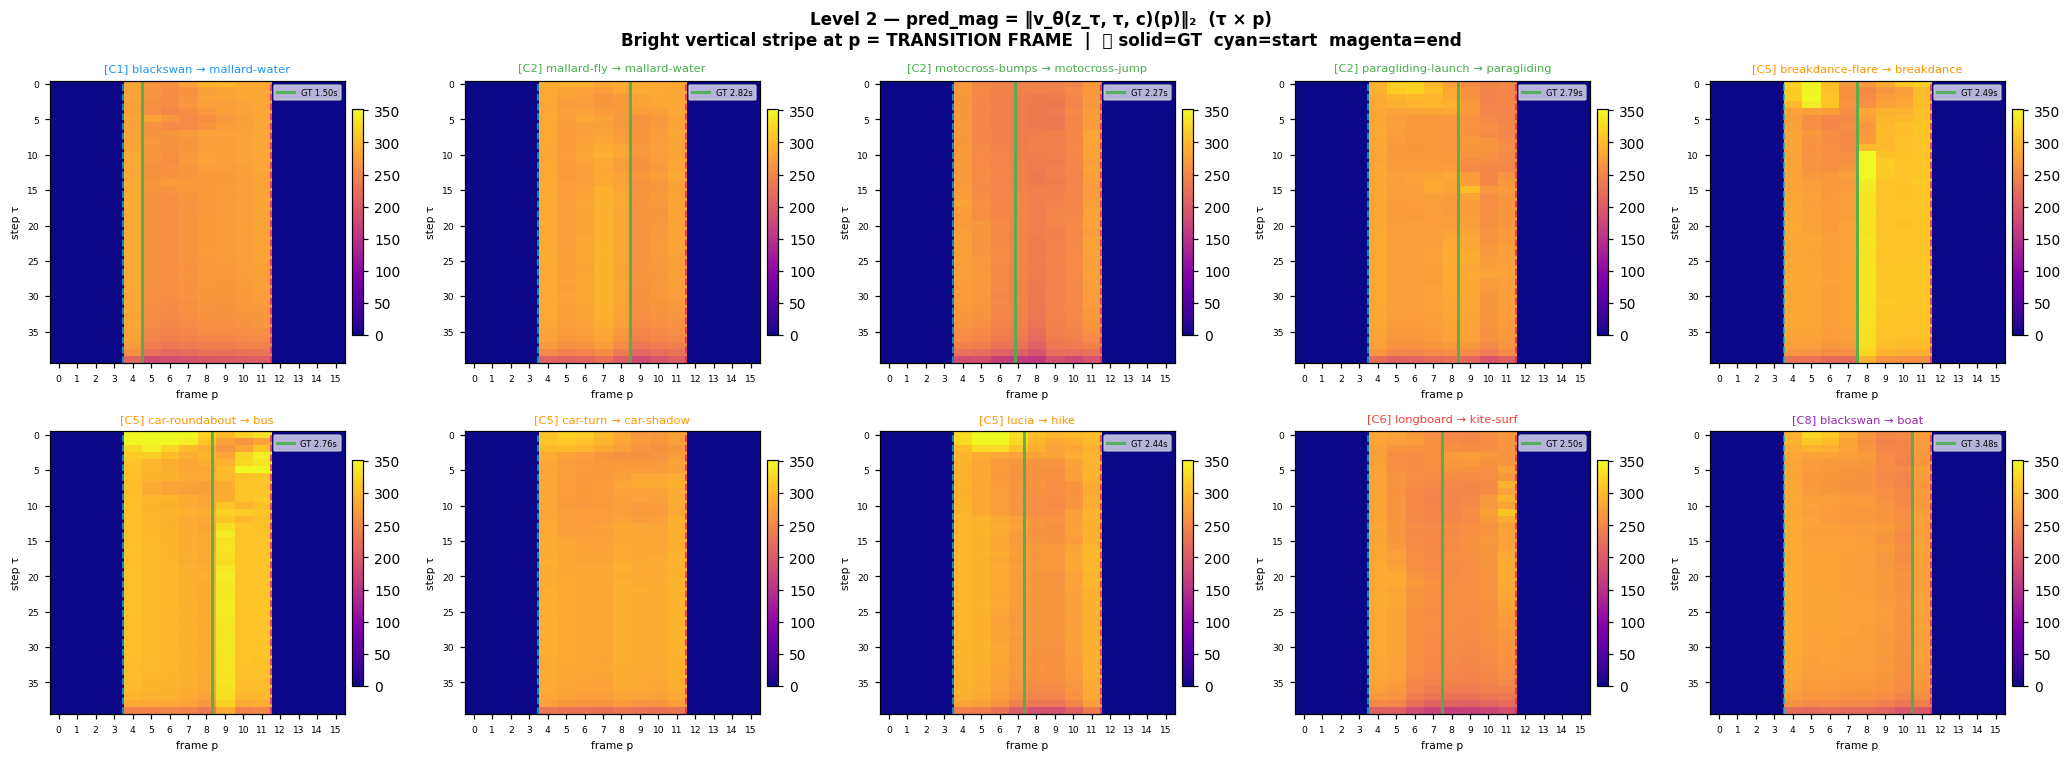

In [6]:
n     = len(records)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.8, nrows * 3.5))
axes_flat  = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else list(axes)
if nrows == 1 and ncols > 1:
    axes_flat = list(axes)
elif nrows > 1:
    axes_flat = [ax for row in axes for ax in (row if hasattr(row, "__iter__") else [row])]

fig.suptitle(
    "Level 2 — pred_mag = ‖v_θ(z_τ, τ, c)(p)‖₂  (τ × p)\n"
    "Bright vertical stripe at p = TRANSITION FRAME  |  🟢 solid=GT  cyan=start  magenta=end",
    fontsize=11, fontweight="bold"
)

global_vmax = max(float(np.percentile(r["feats"]["pred_mag"], 99)) for r in records)

for i, (ax, r) in enumerate(zip(axes_flat, records)):
    f   = r["feats"]
    sid = r["sample_id"]
    im  = ax.imshow(f["pred_mag"], aspect="auto", cmap="plasma",
                    vmin=0, vmax=global_vmax, origin="upper", interpolation="nearest",
                    extent=[-0.5, f["F"]-0.5, f["S"]-0.5, -0.5])
    ax.axvline(K_LAT   - 0.5, color="#00BCD4", lw=1.2, ls="--", alpha=0.8)
    ax.axvline(END_IDX - 0.5, color="#E91E63", lw=1.2, ls="--", alpha=0.8)
    gp = gt_latent(sid, gt_dict)
    if gp is not None:
        ax.axvline(gp, color="#4CAF50", lw=2.0, ls="-",
                   label=f"GT {gt_dict[sid]:.2f}s", alpha=0.9)
        ax.legend(fontsize=5.5, loc="upper right", framealpha=0.7)
    ax.set_title(r["short_id"], fontsize=7.5, color=r["color"])
    ax.set_xlabel("frame p", fontsize=7)
    ax.set_ylabel("step τ", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xticks(range(f["F"]))
    plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)

for ax in axes_flat[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


---
## 2.2 — Cross-Sample Curvature + Angular Comparison

All 10 samples overlaid on the same axes. Colour = semantic class.

**Top panel — normalised curvature `‖z₀(p+2)−2z₀(p+1)+z₀(p)‖₂ / max`:**  
Each curve normalised to [0,1] for shape comparison.
- **Narrow peak** = hard cut at one specific frame
- **Broad hump** = gradual transition
- **Flat** = no transition (similar clips)

**Bottom panel — angular consistency `cos(Δz₀(p), Δz₀(p+1))`:**  
Red-filled region = cos < 0 = the latent trajectory reverses direction.

**Solid vertical lines** = GT annotations. 
Do all GT lines land at or near the curvature peak for that sample?


NameError: name 'add_gt_vline' is not defined

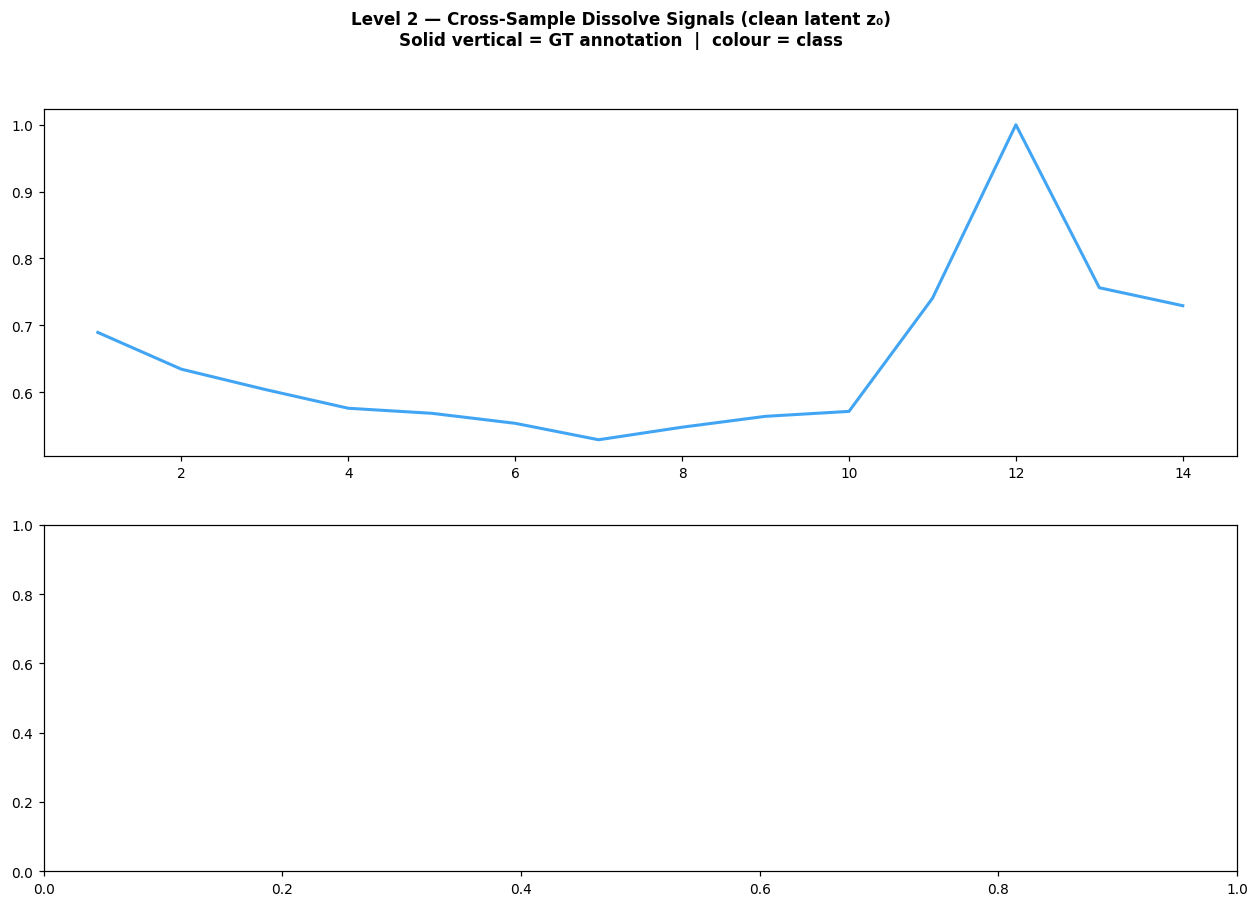

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
fig.suptitle(
    "Level 2 — Cross-Sample Dissolve Signals (clean latent z₀)\n"
    "Solid vertical = GT annotation  |  colour = class",
    fontsize=11, fontweight="bold"
)

F    = records[0]["feats"]["F"]
f_c2 = np.arange(F - 2) + 1.0

for r in records:
    f    = r["feats"]
    col  = r["color"]
    lbl  = r["short_id"]
    sid  = r["sample_id"]

    c0   = f["curvature_z0"]
    c0_n = c0 / (c0.max() + 1e-8)
    ax1.plot(f_c2, c0_n, "-", color=col, lw=2.0, alpha=0.85, label=lbl)
    add_gt_vline(ax1, sid, gt_dict, color=col, lw=1.8, ls="-", label=False)

    ax2.plot(f_c2, f["angular_z0"], "-", color=col, lw=2.0, alpha=0.85, label=lbl)
    add_gt_vline(ax2, sid, gt_dict, color=col, lw=1.8, ls="-", label=False)

ax1.set_title("Normalised curvature_z0 = ‖z₀(p+2)−2z₀(p+1)+z₀(p)‖₂ / max", fontsize=9)
ax1.set_ylabel("curvature / max", fontsize=9)
ax1.set_ylim(-0.05, 1.15)
ax1.legend(fontsize=7, ncol=2, loc="upper left", framealpha=0.8)
ax1.axhline(0, color="gray", lw=0.5, ls=":")

ax2.set_title("angular_z0 = cos(z₀(p+1)−z₀(p),  z₀(p+2)−z₀(p+1))", fontsize=9)
ax2.set_ylabel("cosine", fontsize=9)
ax2.set_ylim(-1.15, 1.15)
ax2.axhline(0, color="gray", lw=0.8, ls=":")
ax2.fill_between(f_c2, -1.15, 0, alpha=0.04, color="red", label="reversal zone")
ax2.legend(fontsize=7, ncol=2, loc="upper left", framealpha=0.8)

for ax in (ax1, ax2):
    shade_cond(ax, F-2, F=F)
    ax.set_xticks(range(F))
    ax.set_xlim(-0.5, F-0.5)
    ax.set_xlabel("frame  p", fontsize=9)
    ax.tick_params(labelsize=8)
    ax2b = ax.twiny()
    ax2b.set_xlim(-0.5, F-0.5)
    ax2b.set_xticks(range(F))
    ax2b.set_xticklabels(
        [f"{p*LTX_TEMPORAL_SCALE/VIDEO_FPS:.1f}s" for p in range(F)],
        fontsize=5.5, rotation=45
    )

plt.tight_layout()
plt.show()


---
## 2.3 — Latent Curvature Frame Evolution over Denoising Steps

This plot tracks **where the curvature peak in `z_t[τ]` falls at each denoising step τ**.

Each line = `argmax_p curvature_z[τ, :]` — the frame with the highest curvature at step τ.

**What this shows:**  
As the model denoises (τ: 0 → 39), the frame-sequence geometry becomes more structured.
The curvature peak tracks which frame has the sharpest "bend" in the latent trajectory
at each denoising moment.

- **Flat horizontal line in the gold band from τ=0** → the transition location is already
  encoded in the noise geometry from the very first step.
- **Starts outside gold band, then settles in** → boundary frames dominate early, model
  progressively concentrates the transition into the free-middle region.
- **Jumpy across all 40 steps** → no stable transition signal.

**Dotted horizontal lines** = GT latent frame per sample.  
A line converging toward the dotted GT line → the curvature-peak signal tracks ground truth.

> **Shaded bands:** 🟡 gold = free-middle `p=4..11` · 🔵 cyan = start-clip · 🟣 magenta = end-clip.


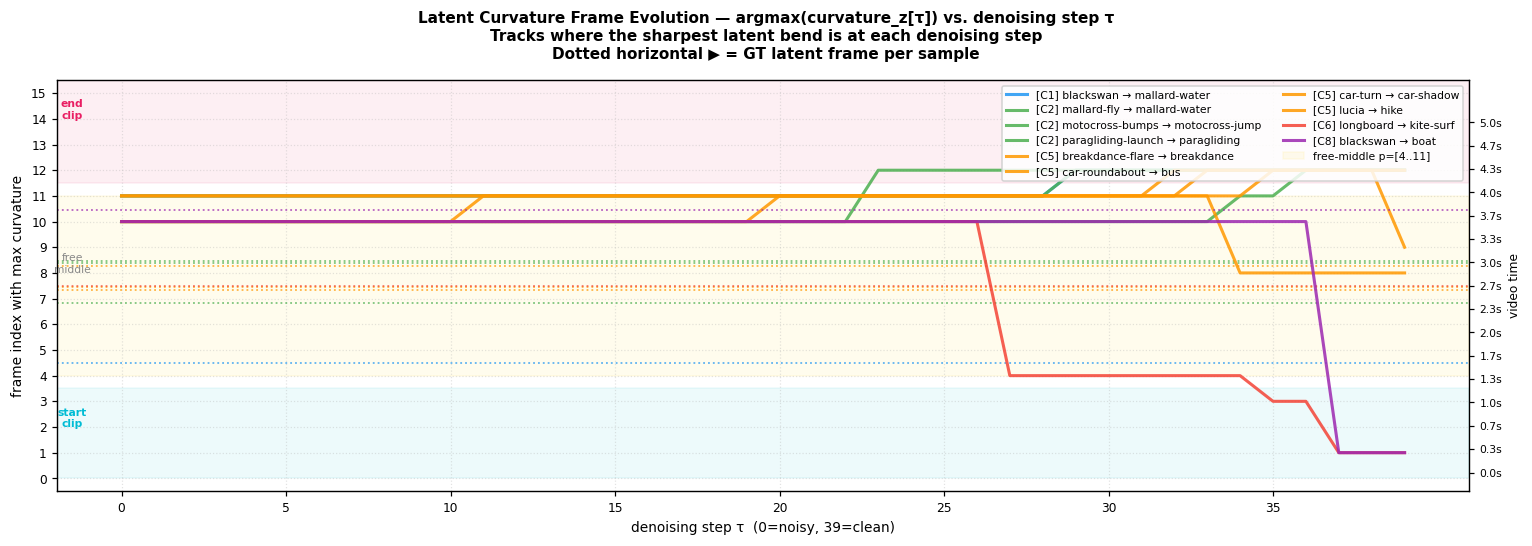

Dotted horizontals = GT latent frame per sample.


In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle(
    "Latent Curvature Frame Evolution — argmax(curvature_z[τ]) vs. denoising step τ\n"
    "Tracks where the sharpest latent bend is at each denoising step\n"
    "Dotted horizontal ▶ = GT latent frame per sample",
    fontsize=10, fontweight="bold"
)

S     = records[0]["feats"]["S"]
steps = np.arange(S)

for r in records:
    f   = r["feats"]
    col = r["color"]
    lbl = r["short_id"]
    ax.plot(steps, f["dissolve_by_step"], "-", color=col, lw=2.0, alpha=0.85, label=lbl)
    gp = gt_latent(r["sample_id"], gt_dict)
    if gp is not None:
        ax.axhline(gp, color=col, lw=1.2, ls=":", alpha=0.7)

ax.axhspan(K_LAT,      END_IDX - 1,   alpha=0.07, color="gold",
           label=f"free-middle p=[{K_LAT}..{END_IDX-1}]")
ax.axhspan(0,          K_LAT - 0.5,   alpha=0.07, color="#00BCD4")
ax.axhspan(END_IDX - 0.5, F_PRIME,    alpha=0.07, color="#E91E63")
ax.set_xlabel("denoising step τ  (0=noisy, 39=clean)", fontsize=9)
ax.set_ylabel("frame index with max curvature", fontsize=9)
ax.set_xticks(steps[::5])
ax.set_yticks(range(F_PRIME))

ax2y = ax.twinx()
ax2y.set_ylim(ax.get_ylim())
ax2y.set_yticks(list(range(F_PRIME)))
ax2y.set_yticklabels([f"{p*LTX_TEMPORAL_SCALE/VIDEO_FPS:.1f}s" for p in range(F_PRIME)], fontsize=7)
ax2y.set_ylabel("video time", fontsize=8)

ax.set_ylim(-0.5, F_PRIME - 0.5)
ax.tick_params(labelsize=8)
ax.legend(fontsize=7, ncol=2, loc="upper right", framealpha=0.85)
ax.grid(axis="both", linestyle=":", alpha=0.35)
ax.text(-1.5, K_LAT/2,           "start\nclip", fontsize=7, ha="center", color="#00BCD4", fontweight="bold")
ax.text(-1.5, (K_LAT+END_IDX)/2, "free\nmiddle", fontsize=7, ha="center", color="#888")
ax.text(-1.5, (END_IDX+F_PRIME)/2,"end\nclip",  fontsize=7, ha="center", color="#E91E63", fontweight="bold")
plt.tight_layout()
plt.show()
print("Dotted horizontals = GT latent frame per sample.")


---
## 2.4 — Velocity Profile by Denoising Third

Each sample's `pred_mag` profile is averaged over three equal thirds of the 40-step
denoising process:

| Column | Steps | What it captures |
|--------|-------|-----------------|
| **Early** (τ=0–13) | First 35% | Velocity in heavily noised space — prior about where large changes are needed |
| **Middle** (τ=14–26) | Middle 32% | Structure forming — velocity stabilising |
| **Final** (τ=27–39) | Last 33% | Detail refinement — lower overall velocity |

A transition frame with **consistently tall bars across all three thirds** = committed
from the very first step.

🟢 Green line = GT annotation.


NameError: name 'add_gt_vline' is not defined

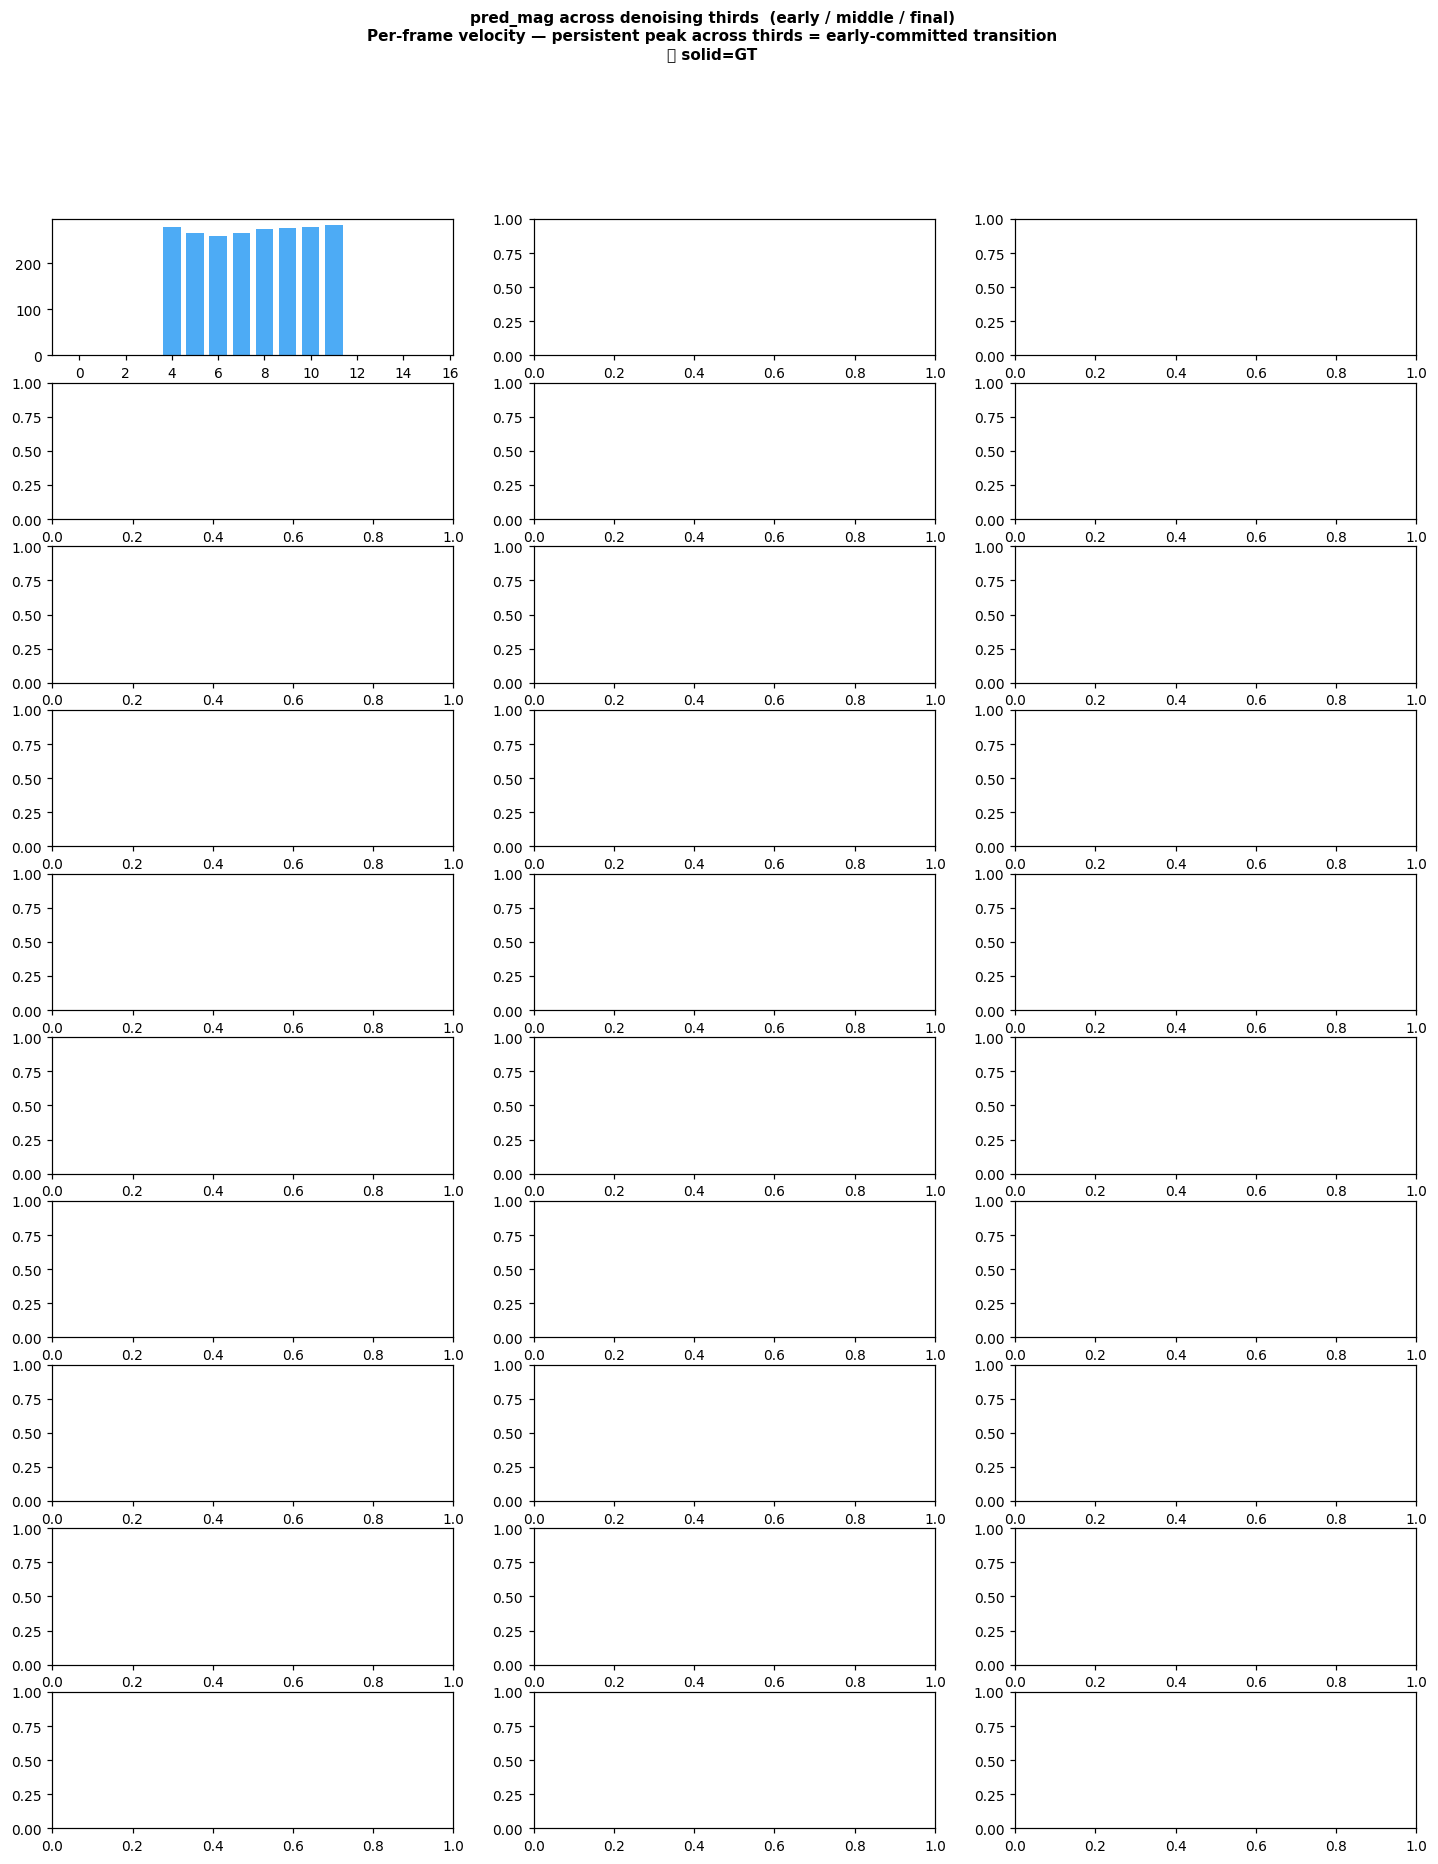

In [10]:
fig, axes = plt.subplots(len(records), 3, figsize=(16, len(records) * 1.9))
fig.suptitle(
    "pred_mag across denoising thirds  (early / middle / final)\n"
    "Per-frame velocity — persistent peak across thirds = early-committed transition\n"
    "🟢 solid=GT",
    fontsize=10, fontweight="bold"
)

for row, r in enumerate(records):
    f      = r["feats"]
    pm     = f["pred_mag"]
    S      = f["S"]; F = f["F"]
    col    = r["color"]
    frames = np.arange(F)
    sid    = r["sample_id"]

    thirds = [
        (0,      S//3,   f"early  τ=0–{S//3-1}"),
        (S//3,   2*S//3, f"middle τ={S//3}–{2*S//3-1}"),
        (2*S//3, S,      f"final  τ={2*S//3}–{S-1}"),
    ]
    for tcol, (t0, t1, tlbl) in enumerate(thirds):
        ax = axes[row, tcol] if len(records) > 1 else axes[tcol]
        mean_pm = pm[t0:t1].mean(axis=0)
        ax.bar(frames, mean_pm, width=0.75, color=col, alpha=0.8)
        add_gt_vline(ax, sid, gt_dict, label=(tcol == 2 and row == 0))
        shade_cond(ax, F, F=F)
        ax.set_xlim(-0.5, F-0.5); ax.set_xticks(range(F))
        ax.tick_params(labelsize=6)
        if row == 0: ax.set_title(tlbl, fontsize=8)
        if tcol == 0: ax.set_ylabel(r["short_id"], fontsize=6, labelpad=2)

plt.tight_layout()
plt.show()
